# AutoWorth AI — Used Car Price & Deal Advisor

## Project Overview

AutoWorth AI is a Machine Learning system that predicts the market price of a used car and compares it with the seller's asking price.

The project follows the complete Machine Learning workflow:

**Data Loading → Cleaning → EDA → Feature Engineering → Preprocessing → Model Training → Evaluation → Tuning → Final Model → Deal Advisor**

### Problem Type

Regression

### Target Variable

Price

In [76]:
# Import Libraries

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Regression models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

# Evaluation metrics
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

# Display settings
pd.set_option("display.max_columns", None)

# Reproducibility
RANDOM_STATE = 42

In [77]:
# Upload / Access the Dataset

from google.colab import files

uploaded = files.upload()

Saving archive.zip to archive (1).zip


In [78]:
import zipfile

zip_path = "archive.zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("car_dataset")

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [79]:
# Inspect Files

import os

for root, dirs, files in os.walk("car_dataset"):
    for file in files:
        print(os.path.join(root, file))

car_dataset/vw.csv
car_dataset/toyota.csv
car_dataset/hyundi.csv
car_dataset/vauxhall.csv
car_dataset/merc.csv
car_dataset/bmw.csv
car_dataset/ford.csv
car_dataset/audi.csv
car_dataset/cclass.csv
car_dataset/unclean focus.csv
car_dataset/focus.csv
car_dataset/unclean cclass.csv
car_dataset/skoda.csv


In [80]:
# Load Manufacturer Datasets

file_make_map = {
    "audi.csv": "Audi",
    "bmw.csv": "BMW",
    "ford.csv": "Ford",
    "focus.csv": "Ford",
    "hyundi.csv": "Hyundai",
    "merc.csv": "Mercedes",
    "cclass.csv": "Mercedes",
    "skoda.csv": "Skoda",
    "toyota.csv": "Toyota",
    "vauxhall.csv": "Vauxhall",
    "vw.csv": "Volkswagen"
}

In [81]:
dataframes = []

for file_name, make in file_make_map.items():
    file_path = os.path.join("car_dataset", file_name)

    df_temp = pd.read_csv(file_path)

    # Add manufacturer
    df_temp["Make"] = make

    # Standardize Hyundai tax column name
    if "tax(£)" in df_temp.columns:
        df_temp = df_temp.rename(columns={"tax(£)": "tax"})

    dataframes.append(df_temp)

print(f"Number of datasets loaded: {len(dataframes)}")

Number of datasets loaded: 11


In [82]:
# Combine the Data

df = pd.concat(dataframes, ignore_index=True)

print("Combined dataset shape:", df.shape)

Combined dataset shape: (108540, 10)


In [83]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017,12500,Manual,15735,Petrol,150.0,55.4,1.4,Audi
1,A6,2016,16500,Automatic,36203,Diesel,20.0,64.2,2.0,Audi
2,A1,2016,11000,Manual,29946,Petrol,30.0,55.4,1.4,Audi
3,A4,2017,16800,Automatic,25952,Diesel,145.0,67.3,2.0,Audi
4,A3,2019,17300,Manual,1998,Petrol,145.0,49.6,1.0,Audi


In [84]:
df.tail()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
108535,Eos,2012,5990,Manual,74000,Diesel,125.0,58.9,2.0,Volkswagen
108536,Fox,2008,1799,Manual,88102,Petrol,145.0,46.3,1.2,Volkswagen
108537,Fox,2009,1590,Manual,70000,Petrol,200.0,42.0,1.4,Volkswagen
108538,Fox,2006,1250,Manual,82704,Petrol,150.0,46.3,1.2,Volkswagen
108539,Fox,2007,2295,Manual,74000,Petrol,145.0,46.3,1.2,Volkswagen


In [85]:
df.shape

(108540, 10)

In [86]:
df.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize', 'Make'],
      dtype='object')

In [87]:
# Data Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108540 entries, 0 to 108539
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   model         108540 non-null  object 
 1   year          108540 non-null  int64  
 2   price         108540 non-null  int64  
 3   transmission  108540 non-null  object 
 4   mileage       108540 non-null  int64  
 5   fuelType      108540 non-null  object 
 6   tax           99187 non-null   float64
 7   mpg           99187 non-null   float64
 8   engineSize    108540 non-null  float64
 9   Make          108540 non-null  object 
dtypes: float64(3), int64(3), object(4)
memory usage: 8.3+ MB


In [88]:
# Descriptive Statistics
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,108540.000000,108540.000000,108540.000000,99187.000000,99187.000000,108540.000000
mean,2017.098028,16890.124046,23025.928469,120.299838,55.166825,1.661644
std,2.130057,9756.266820,21176.423684,63.150926,16.138522,0.557058
min,1970.000000,450.000000,1.000000,0.000000,0.300000,0.000000
25%,2016.000000,10229.500000,7491.750000,125.000000,47.100000,1.200000
50%,2017.000000,14698.000000,17265.000000,145.000000,54.300000,1.600000
75%,2019.000000,20940.000000,32236.000000,145.000000,62.800000,2.000000
max,2060.000000,159999.000000,323000.000000,580.000000,470.800000,6.600000


In [89]:
df.describe(include="object")

,model,transmission,fuelType,Make
count,108540,108540,108540,108540
unique,195,4,5,9
top,Focus,Manual,Petrol,Ford
freq,10042,61308,59875,23419


In [90]:
# Missing Values
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
missing_values

,0
tax,9353
mpg,9353


In [91]:
# Duplicate Rows
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 2273


In [92]:
# Manufacturer Distribution

df["Make"].value_counts()

,count
Make,
Ford,23419
Mercedes,17018
Volkswagen,15157
Vauxhall,13632
BMW,10781
Audi,10668
Toyota,6738
Skoda,6267
Hyundai,4860


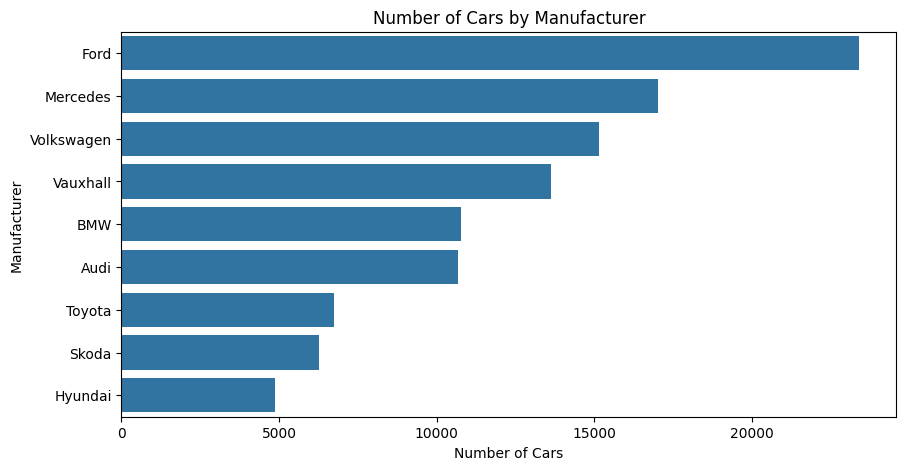

In [93]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    y="Make",
    order=df["Make"].value_counts().index
)

plt.title("Number of Cars by Manufacturer")
plt.xlabel("Number of Cars")
plt.ylabel("Manufacturer")

plt.show()

### Observation

The dataset contains used cars from nine manufacturers. The number of observations varies between manufacturers, so the dataset is not perfectly balanced across brands.

## Data Quality Investigation

Before cleaning, the main data quality issues were investigated rather than removed automatically.

The investigation covered:

* Missing values
* Duplicate rows
* Invalid years
* Suspicious prices and mileage
* Suspicious engine sizes
* Unusual MPG values
* Inconsistent categorical values

Cleaning decisions were based on the observed data and the results of these checks.

In [94]:
# Missing Values

missing_by_make = (
    df.groupby("Make")[["tax", "mpg"]]
    .apply(lambda x: x.isnull().sum())
)

missing_by_make

,tax,mpg
Make,,
Audi,0,0
BMW,0,0
Ford,5454,5454
Hyundai,0,0
Mercedes,3899,3899
Skoda,0,0
Toyota,0,0
Vauxhall,0,0
Volkswagen,0,0


In [95]:
missing_percentage = (
    df.groupby("Make")[["tax", "mpg"]]
    .apply(lambda x: x.isnull().mean() * 100)
    .round(2)
)

missing_percentage

,tax,mpg
Make,,
Audi,0.00,0.00
BMW,0.00,0.00
Ford,23.29,23.29
Hyundai,0.00,0.00
Mercedes,22.91,22.91
Skoda,0.00,0.00
Toyota,0.00,0.00
Vauxhall,0.00,0.00
Volkswagen,0.00,0.00


In [96]:
# Duplicate Investigation

duplicate_count = df.duplicated().sum()

duplicate_percentage = duplicate_count / len(df) * 100

print("Duplicate rows:", duplicate_count)
print(f"Duplicate percentage: {duplicate_percentage:.2f}%")

Duplicate rows: 2273
Duplicate percentage: 2.09%


In [97]:
df[df.duplicated(keep=False)].sort_values(
    by=["Make", "model", "year", "price"]
).head(20)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
4000,A1,2019,19990,Manual,2348,Petrol,145.0,50.4,1.0,Audi
5036,A1,2019,19990,Manual,2348,Petrol,145.0,50.4,1.0,Audi
4469,A1,2019,20595,Manual,6000,Petrol,145.0,47.9,1.0,Audi
4522,A1,2019,20595,Manual,6000,Petrol,145.0,47.9,1.0,Audi
4826,A1,2019,20595,Manual,6000,Petrol,145.0,47.9,1.0,Audi
5169,A1,2019,20595,Manual,6000,Petrol,145.0,47.9,1.0,Audi
7430,A1,2019,22000,Semi-Auto,7500,Petrol,150.0,40.9,2.0,Audi
7431,A1,2019,22000,Semi-Auto,7500,Petrol,150.0,40.9,2.0,Audi
8600,A1,2019,22450,Automatic,6481,Petrol,150.0,40.9,2.0,Audi
8601,A1,2019,22450,Automatic,6481,Petrol,150.0,40.9,2.0,Audi


In [98]:
# Investigate Year

df["year"].value_counts().sort_index()

,count
year,
1970,2
1991,1
1995,1
1996,2
1997,4
1998,9
1999,6
2000,9
2001,20


In [99]:
df[
    (df["year"] < 1990) |
    (df["year"] > 2025)
]["year"].value_counts().sort_index()

,count
year,
1970,2
2060,1


In [100]:
# Investigate Price

df["price"].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

,price
count,108540.000000
mean,16890.124046
std,9756.266820
min,450.000000
1%,3990.000000
5%,6499.000000
25%,10229.500000
50%,14698.000000
75%,20940.000000
95%,33998.000000


In [101]:
df.sort_values("price", ascending=False)[
    ["Make", "model", "year", "price", "mileage", "engineSize"]
].head(20)

,Make,model,year,price,mileage,engineSize
55927,Mercedes,G Class,2020,159999,1350,4.0
59772,Mercedes,G Class,2020,154998,3000,4.0
49733,Mercedes,SL CLASS,2011,149948,3000,6.2
4783,Audi,R8,2020,145000,2000,5.2
58465,Mercedes,A Class,2019,140319,785,4.0
56114,Mercedes,G Class,2018,139995,13046,4.0
49736,Mercedes,G Class,2019,139948,12000,4.0
58861,Mercedes,A Class,2019,139559,1000,4.0
58549,Mercedes,A Class,2020,138439,1000,4.0
2255,Audi,R8,2020,137995,70,5.2


In [102]:
# Investigate Mileage

df["mileage"].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
)

,mileage
count,108540.000000
mean,23025.928469
std,21176.423684
min,1.000000
1%,10.000000
5%,1000.000000
25%,7491.750000
50%,17265.000000
75%,32236.000000
95%,65000.000000


In [103]:
df.sort_values("mileage", ascending=False)[
    ["Make", "model", "year", "price", "mileage"]
].head(20)

,Make,model,year,price,mileage
9822,Audi,A6,2008,2490,323000
72815,Skoda,Octavia,2010,1190,300000
90570,Vauxhall,Zafira,2013,1395,279000
61072,Mercedes,V Class,2010,6949,259000
72331,Skoda,Octavia,2010,1485,250650
72838,Skoda,Octavia,2009,2750,241565
62632,Mercedes,A Class,2016,16249,240494
20087,BMW,X5,2012,7250,214000
106872,Volkswagen,Caravelle,2012,11995,212000
98651,Volkswagen,Golf,2009,2250,193000


In [104]:
df[df["mileage"] <= 100][
    ["Make", "model", "year", "price", "mileage"]
].head(20)

,Make,model,year,price,mileage
198,Audi,Q7,2020,62985,10
207,Audi,A5,2019,28985,18
211,Audi,A6,2019,31985,27
215,Audi,Q2,2019,23685,37
220,Audi,Q5,2020,37985,10
221,Audi,Q7,2019,49985,10
222,Audi,Q7,2019,59995,10
223,Audi,Q5,2020,47895,10
224,Audi,A4,2020,31985,10
229,Audi,Q3,2019,34985,10


In [105]:
# Investigate Engine Size

(df["engineSize"] == 0).sum()

np.int64(286)

In [106]:
df[df["engineSize"] == 0][
    ["Make", "model", "year", "price", "fuelType", "engineSize"]
].head(30)

,Make,model,year,price,fuelType,engineSize
7505,Audi,Q5,2019,44790,Petrol,0.0
7506,Audi,Q3,2019,32788,Diesel,0.0
7516,Audi,Q3,2020,29944,Petrol,0.0
7517,Audi,Q3,2020,33333,Diesel,0.0
7518,Audi,Q3,2020,29944,Petrol,0.0
7519,Audi,Q3,2020,37990,Petrol,0.0
7521,Audi,Q5,2020,49790,Petrol,0.0
7542,Audi,Q3,2019,31888,Petrol,0.0
7545,Audi,Q2,2020,24988,Petrol,0.0
7546,Audi,A3,2017,17390,Petrol,0.0


In [107]:
# Investigate MPG

df["mpg"].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
)

,mpg
count,99187.000000
mean,55.166825
std,16.138522
min,0.300000
1%,29.700000
5%,35.800000
25%,47.100000
50%,54.300000
75%,62.800000
95%,74.300000


In [108]:
df.sort_values("mpg", ascending=False)[
    ["Make", "model", "year", "fuelType", "mpg", "engineSize"]
].head(20)

,Make,model,year,fuelType,mpg,engineSize
21198,BMW,i3,2017,Other,470.8,0.6
18856,BMW,i3,2015,Other,470.8,0.6
18015,BMW,i3,2017,Hybrid,470.8,0.0
19503,BMW,i3,2015,Electric,470.8,1.0
19288,BMW,i3,2017,Other,470.8,0.6
15534,BMW,i3,2014,Hybrid,470.8,0.0
13945,BMW,i3,2016,Hybrid,470.8,0.0
17967,BMW,i3,2017,Hybrid,470.8,0.0
17544,BMW,i3,2016,Hybrid,470.8,0.0
16948,BMW,i3,2017,Hybrid,470.8,0.0


In [109]:
df[df["mpg"] < 10][
    ["Make", "model", "year", "fuelType", "mpg", "engineSize"]
].head(20)

,Make,model,year,fuelType,mpg,engineSize
11905,BMW,X3,2020,Hybrid,5.5,2.0
12784,BMW,X3,2020,Hybrid,5.5,2.0
13806,BMW,3 Series,2019,Hybrid,8.8,2.0
15659,BMW,3 Series,2019,Hybrid,8.8,2.0
16183,BMW,3 Series,2019,Hybrid,8.8,2.0
16628,BMW,3 Series,2019,Hybrid,8.8,2.0
16800,BMW,X3,2020,Hybrid,5.5,2.0
16840,BMW,X3,2020,Hybrid,5.5,2.0
16866,BMW,X3,2020,Hybrid,5.5,2.0
17157,BMW,3 Series,2019,Hybrid,8.8,2.0


In [110]:
# Categorical Values

categorical_columns = [
    "model",
    "transmission",
    "fuelType",
    "Make"
]

for col in categorical_columns:
    print("\n")
    print(df[col].value_counts())



model
 Focus              10042
 C Class             7646
 Fiesta              6557
 Golf                4863
 Corsa               3441
                    ...  
220                     1
 Transit Tourneo        1
 Ranger                 1
 Amica                  1
 Accent                 1
Name: count, Length: 195, dtype: int64


transmission
Manual       61308
Semi-Auto    24903
Automatic    22319
Other           10
Name: count, dtype: int64


fuelType
Petrol      59875
Diesel      45177
Hybrid       3229
Other         253
Electric        6
Name: count, dtype: int64


Make
Ford          23419
Mercedes      17018
Volkswagen    15157
Vauxhall      13632
BMW           10781
Audi          10668
Toyota         6738
Skoda          6267
Hyundai        4860
Name: count, dtype: int64


In [111]:
df["transmission"].value_counts()

,count
transmission,
Manual,61308
Semi-Auto,24903
Automatic,22319
Other,10


In [112]:
df["fuelType"].value_counts()

,count
fuelType,
Petrol,59875
Diesel,45177
Hybrid,3229
Other,253
Electric,6


In [113]:
df["Make"].value_counts()

,count
Make,
Ford,23419
Mercedes,17018
Volkswagen,15157
Vauxhall,13632
BMW,10781
Audi,10668
Toyota,6738
Skoda,6267
Hyundai,4860


In [114]:
df[df["year"] == 1970][
    ["Make", "model", "year", "price", "transmission",
     "mileage", "fuelType", "tax", "mpg", "engineSize"]
]

,Make,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
61800,Mercedes,M Class,1970,24999,Automatic,14000,Diesel,305.0,39.2,0.0
90588,Vauxhall,Zafira,1970,10495,Manual,37357,Petrol,200.0,42.2,1.4


In [115]:
df[df["engineSize"] == 0]["fuelType"].value_counts()

,count
fuelType,
Petrol,172
Diesel,73
Hybrid,38
Electric,2
Other,1


In [116]:
df[df["engineSize"] == 0].groupby(
    ["fuelType", "Make"]
).size().sort_values(ascending=False)

fuelType  Make      
Petrol    Ford          54
          Audi          41
Hybrid    BMW           33
Petrol    Hyundai       31
          Vauxhall      26
Diesel    Hyundai       16
          Audi          16
          Mercedes      10
          BMW            9
          Ford           8
Petrol    Volkswagen     8
Diesel    Volkswagen     7
          Vauxhall       5
Petrol    Toyota         4
          Skoda          3
          BMW            3
Diesel    Skoda          2
Electric  BMW            2
Hybrid    Vauxhall       2
          Toyota         2
Petrol    Mercedes       2
Other     Mercedes       1
Hybrid    Ford           1
dtype: int64

In [117]:
df[df["engineSize"] == 0].groupby(
    ["Make", "model", "fuelType"]
).size().sort_values(ascending=False).head(30)

Make        model     fuelType
BMW         i3        Hybrid      33
Audi        Q3        Petrol      21
Ford        Fiesta    Petrol      19
            Focus     Petrol      17
Hyundai     I10       Petrol      17
Vauxhall    Astra     Petrol      12
Hyundai     I20       Petrol       8
Ford        EcoSport  Petrol       7
Hyundai     Tucson    Diesel       7
Audi        A3        Petrol       6
            Q3        Diesel       6
            Q2        Petrol       6
Ford        KA        Petrol       6
            Focus     Diesel       6
Vauxhall    Corsa     Petrol       6
Mercedes    A Class   Diesel       5
Vauxhall    Insignia  Petrol       5
BMW         3 Series  Diesel       4
Ford        Ka+       Petrol       4
Audi        Q5        Petrol       4
Toyota      Aygo      Petrol       3
Hyundai     I30       Diesel       3
Volkswagen  Tiguan    Diesel       3
            Passat    Petrol       3
Hyundai     I800      Diesel       3
            Tucson    Petrol       3
Audi        S4        Diesel       3
BMW         1 Series  Diesel       3
Toyota      Yaris     Hybrid       2
Vauxhall    Astra     Diesel       2
dtype: int64

## Data Cleaning

The following cleaning decisions were made based on the data quality investigation:

* Exact duplicate rows were removed.
* Invalid years (1970 and 2060) were removed.
* Missing `tax` and `mpg` values were retained for later imputation.
* `engineSize = 0` was treated as missing.
* Extreme price and mileage values were retained because they were not confirmed as errors.
* Unusual MPG values were retained because they were not proven to be invalid.


In [118]:
# Create a copy before cleaning
df_clean = df.copy()

# 1. Remove exact duplicate rows
before_duplicates = len(df_clean)

df_clean = df_clean.drop_duplicates().reset_index(drop=True)

removed_duplicates = before_duplicates - len(df_clean)

print("Duplicate rows removed:", removed_duplicates)
print("Dataset shape after removing duplicates:", df_clean.shape)

Duplicate rows removed: 2273
Dataset shape after removing duplicates: (106267, 10)


In [119]:
# Remove invalid vehicle years
invalid_years = [1970, 2060]

before_year_cleaning = len(df_clean)

df_clean = df_clean[
    ~df_clean["year"].isin(invalid_years)
].reset_index(drop=True)

removed_invalid_years = before_year_cleaning - len(df_clean)

print("Invalid year rows removed:", removed_invalid_years)
print("Dataset shape after year cleaning:", df_clean.shape)

Invalid year rows removed: 3
Dataset shape after year cleaning: (106264, 10)


In [120]:
# Replace invalid zero engine sizes with missing values
zero_engine_size = (df_clean["engineSize"] == 0).sum()

df_clean.loc[df_clean["engineSize"] == 0, "engineSize"] = np.nan

print("Engine size values converted to NaN:", zero_engine_size)
print("Missing engineSize values:", df_clean["engineSize"].isna().sum())

Engine size values converted to NaN: 280
Missing engineSize values: 280


In [121]:
print("Final cleaned dataset shape:", df_clean.shape)

print("\nMissing values:")
print(df_clean.isnull().sum())

print("\nDuplicate rows:")
print(df_clean.duplicated().sum())

print("\nYear range:")
print(df_clean["year"].min(), "to", df_clean["year"].max())

print("\nInvalid engine sizes (0):")
print((df_clean["engineSize"] == 0).sum())

Final cleaned dataset shape: (106264, 10)

Missing values:
model              0
year               0
price              0
transmission       0
mileage            0
fuelType           0
tax             8555
mpg             8555
engineSize       280
Make               0
dtype: int64

Duplicate rows:
0

Year range:
1991 to 2020

Invalid engine sizes (0):
0


## Cleaning Summary

After investigating the data quality issues, the dataset was cleaned using evidence-based decisions.

- 2,273 exact duplicate rows were removed.
- 3 invalid year records (1970 and 2060) were removed.
- 280 invalid `engineSize` values equal to 0 were converted to missing values.
- Extreme price and mileage values were retained because they were not confirmed to be data-entry errors.
- Unusual MPG values were retained because they were associated with specific vehicle types and were not proven to be invalid.
- Missing `tax`, `mpg`, and `engineSize` values were retained for later imputation during the preprocessing stage.

The cleaned dataset contains **106,264 rows and 10 columns**, with no duplicate rows and a valid year range from 1991 to 2020.

## Exploratory Data Analysis (EDA)

EDA was performed to examine the distribution of car prices and explore relationships between price and key vehicle characteristics.

The analysis includes price distribution, mileage, year, manufacturer, transmission, fuel type, and numerical correlations.


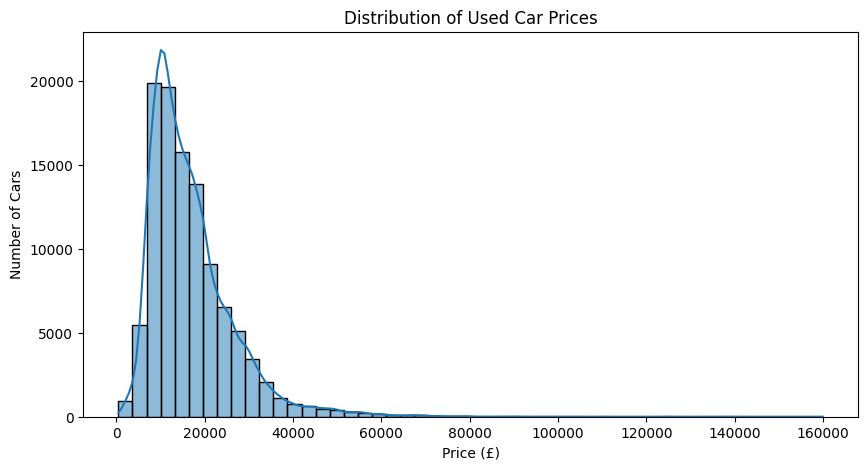

In [122]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

sns.histplot(
    df_clean["price"],
    bins=50,
    kde=True
)

plt.title("Distribution of Used Car Prices")
plt.xlabel("Price (£)")
plt.ylabel("Number of Cars")
plt.show()

**Conclusion:** Car prices are strongly right-skewed. Most vehicles are below £20,000, while a smaller number of high-priced cars create a long right tail.


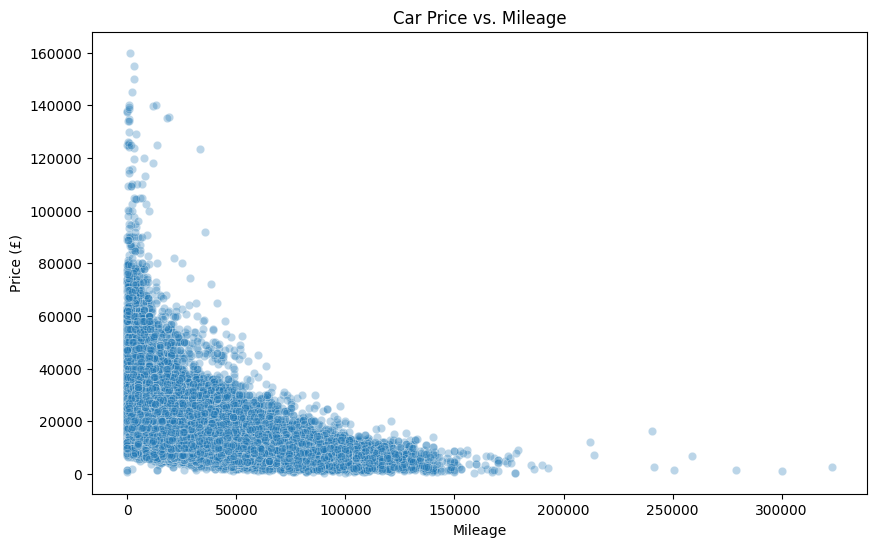

In [123]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_clean,
    x="mileage",
    y="price",
    alpha=0.3
)

plt.title("Car Price vs. Mileage")
plt.xlabel("Mileage")
plt.ylabel("Price (£)")
plt.show()

**Conclusion:** Higher mileage is generally associated with lower car prices, although vehicle age, manufacturer, model, and other specifications also affect price.


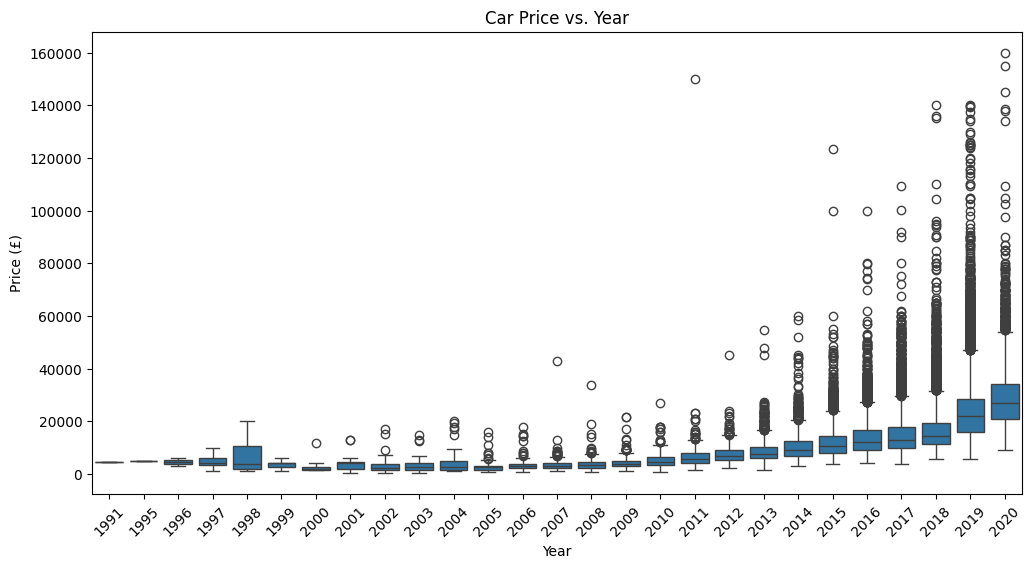

In [124]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_clean,
    x="year",
    y="price"
)

plt.title("Car Price vs. Year")
plt.xlabel("Year")
plt.ylabel("Price (£)")
plt.xticks(rotation=45)
plt.show()

**Conclusion:** Newer vehicles generally have higher prices than older vehicles. Recent years also show greater price variation and more high-priced vehicles.


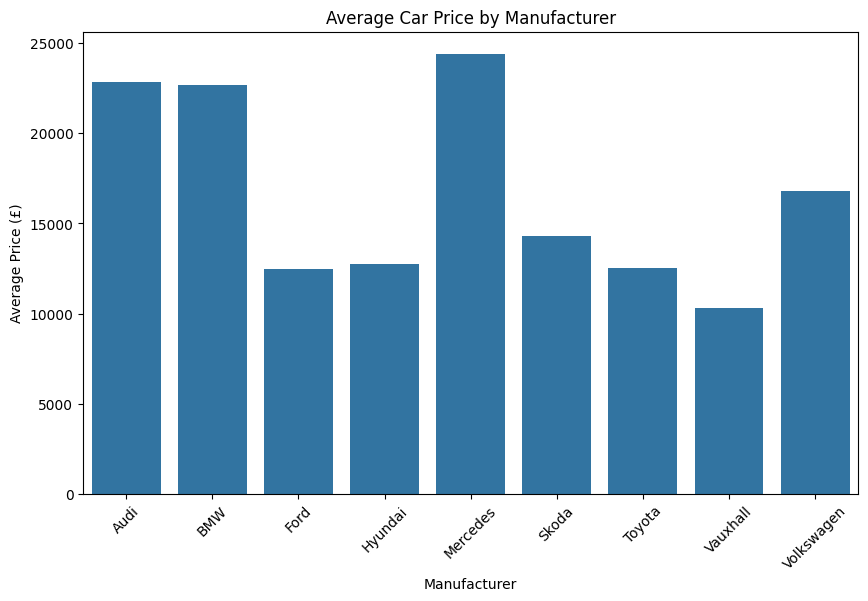

In [125]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_clean,
    x="Make",
    y="price",
    estimator="mean",
    errorbar=None
)

plt.title("Average Car Price by Manufacturer")
plt.xlabel("Manufacturer")
plt.ylabel("Average Price (£)")
plt.xticks(rotation=45)
plt.show()

**Conclusion:** Average prices differ across manufacturers, with Mercedes, Audi, and BMW generally showing higher average prices than the other manufacturers in this dataset.


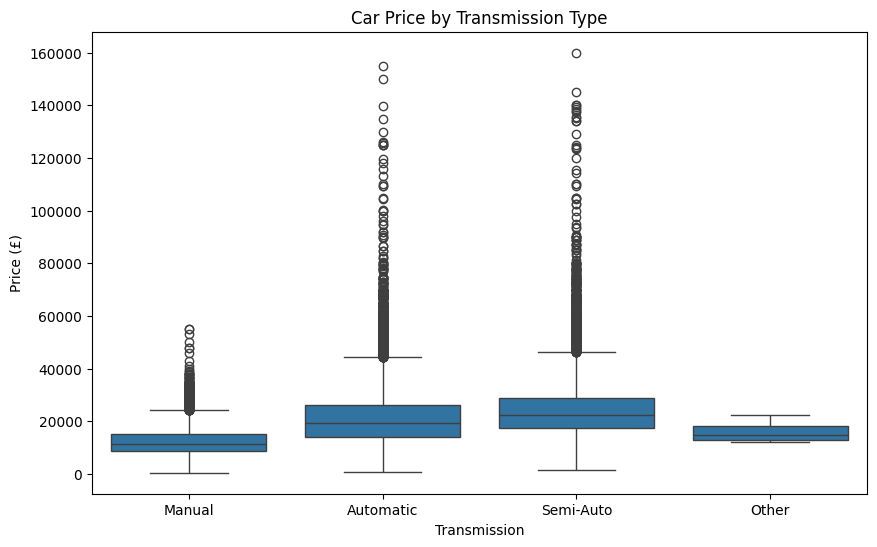

In [126]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_clean,
    x="transmission",
    y="price"
)

plt.title("Car Price by Transmission Type")
plt.xlabel("Transmission")
plt.ylabel("Price (£)")
plt.show()

**Conclusion:** Automatic and Semi-Auto vehicles generally have higher median prices than Manual vehicles in this dataset.


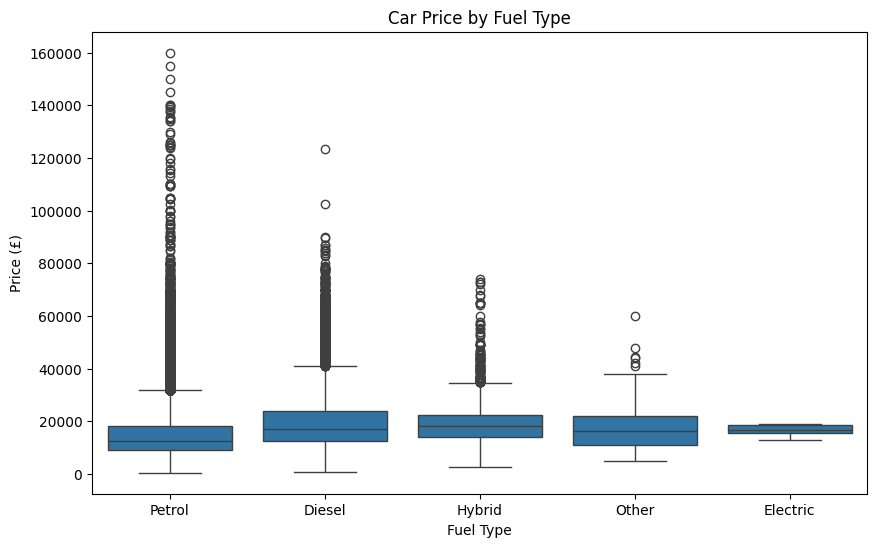

In [127]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_clean,
    x="fuelType",
    y="price"
)

plt.title("Car Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Price (£)")
plt.show()

**Conclusion:** Price distributions differ across fuel types. Diesel and Hybrid vehicles have higher median prices than Petrol vehicles in this dataset.


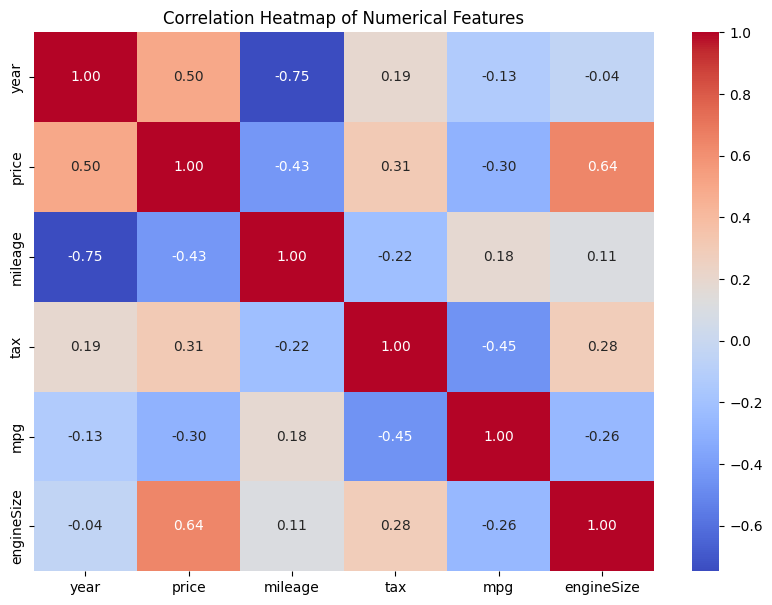

In [128]:
plt.figure(figsize=(10, 7))

correlation_matrix = df_clean.select_dtypes(include="number").corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Features")
plt.show()

**Conclusion:** `engineSize` has the strongest positive linear correlation with price, while `mileage` has a moderate negative correlation. These correlations describe linear relationships and do not imply causation.


## Train / Validation / Test Split

The cleaned dataset was divided into:

* **Training: 70%** — used to train the models.
* **Validation: 15%** — used for model comparison and tuning.
* **Test: 15%** — kept untouched until final evaluation.

The split was performed before fitting preprocessing steps to prevent data leakage.


In [129]:
# Separate features and target
X = df_clean.drop(columns=["price"])
y = df_clean["price"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (106264, 9)
Target shape: (106264,)


In [130]:
from sklearn.model_selection import train_test_split

# First split: 70% training and 30% temporary data
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

print("Training set:", X_train.shape)
print("Temporary set:", X_temp.shape)

Training set: (74384, 9)
Temporary set: (31880, 9)


In [131]:
# Second split: divide the temporary data equally
# into 15% validation and 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (74384, 9)
Validation set: (15940, 9)
Test set: (15940, 9)


In [132]:
# Verify the split proportions
total = len(df_clean)

print(f"Train: {len(X_train)} rows ({len(X_train) / total:.2%})")
print(f"Validation: {len(X_val)} rows ({len(X_val) / total:.2%})")
print(f"Test: {len(X_test)} rows ({len(X_test) / total:.2%})")

Train: 74384 rows (70.00%)
Validation: 15940 rows (15.00%)
Test: 15940 rows (15.00%)


## Feature Engineering

Three additional features were created to provide the models with useful information about vehicle usage and specifications:

* **Car Age:** `2021 - Year`
* **Mileage Per Year:** `Mileage / Car Age`
* **Engine-MPG Ratio:** `Engine Size / MPG`

A fixed reference year of **2021** was used to keep car age consistent across the dataset.


In [133]:
# Create copies to avoid modifying the original split data
X_train_fe = X_train.copy()
X_val_fe = X_val.copy()
X_test_fe = X_test.copy()

REFERENCE_YEAR = 2021

def create_features(data):
    data = data.copy()

    # 1. Car Age
    data["car_age"] = REFERENCE_YEAR - data["year"]

    # 2. Mileage Per Year
    data["mileage_per_year"] = np.where(
    data["car_age"] > 0,
    data["mileage"] / data["car_age"],
    0
    )

    # 3. Engine Size to MPG Ratio
    data["engine_mpg_ratio"] = (
        data["engineSize"] / data["mpg"]
    )

    return data

In [134]:
X_train_fe = create_features(X_train_fe)
X_val_fe = create_features(X_val_fe)
X_test_fe = create_features(X_test_fe)

print("Training features:", X_train_fe.shape)
print("Validation features:", X_val_fe.shape)
print("Test features:", X_test_fe.shape)

Training features: (74384, 12)
Validation features: (15940, 12)
Test features: (15940, 12)


## Preprocessing

Numerical features were imputed using the median and scaled with `StandardScaler`.

Categorical features were imputed using the most frequent value and encoded using One-Hot Encoding.

The preprocessing pipeline was fitted only on the training data and then applied to validation and test sets to prevent data leakage.


In [135]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Numerical features
numerical_features = [
    "year",
    "mileage",
    "tax",
    "mpg",
    "engineSize",
    "car_age",
    "mileage_per_year",
    "engine_mpg_ratio"
]

# Categorical features
categorical_features = [
    "model",
    "transmission",
    "fuelType",
    "Make"
]

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

Numerical features: ['year', 'mileage', 'tax', 'mpg', 'engineSize', 'car_age', 'mileage_per_year', 'engine_mpg_ratio']
Categorical features: ['model', 'transmission', 'fuelType', 'Make']


In [136]:
# Numerical preprocessing
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine both pipelines
preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [137]:
# Fit the preprocessing pipeline only on the training data
X_train_processed = preprocessor.fit_transform(X_train_fe)

# Transform validation and test data using the fitted preprocessor
X_val_processed = preprocessor.transform(X_val_fe)
X_test_processed = preprocessor.transform(X_test_fe)

print("Training processed shape:", X_train_processed.shape)
print("Validation processed shape:", X_val_processed.shape)
print("Test processed shape:", X_test_processed.shape)

Training processed shape: (74384, 216)
Validation processed shape: (15940, 216)
Test processed shape: (15940, 216)


## Model Training and Evaluation

Five regression models were trained and compared:

* Linear Regression
* Decision Tree
* Random Forest
* Gradient Boosting
* XGBoost

Performance was evaluated using **R², MAE, and RMSE**, with training and validation results compared to check for overfitting.


In [138]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

In [139]:
models = {
    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=100,
        random_state=42
    )
}

In [140]:
from xgboost import XGBRegressor

models["XGBoost"] = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

In [141]:
# Train the Models

import time

model_results = []
trained_models = {}

for name, model in models.items():
    print(f"Training {name}...")

    start_time = time.time()

    model.fit(X_train_processed, y_train)

    training_time = time.time() - start_time

    trained_models[name] = model

    # Predictions
    y_train_pred = model.predict(X_train_processed)
    y_val_pred = model.predict(X_val_processed)

    # Training metrics
    train_r2 = r2_score(y_train, y_train_pred)
    train_mae = mean_absolute_error(y_train, y_train_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))

    # Validation metrics
    val_r2 = r2_score(y_val, y_val_pred)
    val_mae = mean_absolute_error(y_val, y_val_pred)
    val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))

    model_results.append({
        "Model": name,
        "Train R²": train_r2,
        "Validation R²": val_r2,
        "Train MAE": train_mae,
        "Validation MAE": val_mae,
        "Train RMSE": train_rmse,
        "Validation RMSE": val_rmse,
        "Training Time (s)": training_time
    })

    print(f"Completed in {training_time:.2f} seconds")
    print(f"Validation R²: {val_r2:.4f}")
    print("-" * 50)

Training Linear Regression...
Completed in 1.43 seconds
Validation R²: 0.8754
--------------------------------------------------
Training Decision Tree...
Completed in 16.17 seconds
Validation R²: 0.9349
--------------------------------------------------
Training Random Forest...
Completed in 1170.87 seconds
Validation R²: 0.9569
--------------------------------------------------
Training Gradient Boosting...
Completed in 20.81 seconds
Validation R²: 0.8966
--------------------------------------------------
Training XGBoost...
Completed in 0.90 seconds
Validation R²: 0.9374
--------------------------------------------------


In [142]:
# Create Model Comparison Table

results_df = pd.DataFrame(model_results)

results_df = results_df.sort_values(
    by="Validation R²",
    ascending=False
).reset_index(drop=True)

results_df

,Model,Train R²,Validation R²,Train MAE,Validation MAE,Train RMSE,Validation RMSE,Training Time (s)
0,Random Forest,0.993699,0.956891,448.712003,1175.650860,774.866956,2048.149127,1170.874959
1,XGBoost,0.946750,0.937365,1526.247192,1569.290649,2252.572196,2468.803354,0.904703
2,Decision Tree,0.999548,0.934920,20.803950,1453.622805,207.501601,2516.545230,16.167269
3,Gradient Boosting,0.902250,0.896601,2079.689519,2108.961884,3051.936225,3172.033882,20.806953
4,Linear Regression,0.868470,0.875400,2216.674850,2188.832017,3540.221131,3482.077759,1.431562


In [143]:
# Round the Results

display(
    results_df.style.format({
        "Train R²": "{:.4f}",
        "Validation R²": "{:.4f}",
        "Train MAE": "£{:,.2f}",
        "Validation MAE": "£{:,.2f}",
        "Train RMSE": "£{:,.2f}",
        "Validation RMSE": "£{:,.2f}",
        "Training Time (s)": "{:.2f}"
    })
)

,Model,Train R²,Validation R²,Train MAE,Validation MAE,Train RMSE,Validation RMSE,Training Time (s)
0,Random Forest,0.9937,0.9569,£448.71,"£1,175.65",£774.87,"£2,048.15",1170.87
1,XGBoost,0.9467,0.9374,"£1,526.25","£1,569.29","£2,252.57","£2,468.80",0.90
2,Decision Tree,0.9995,0.9349,£20.80,"£1,453.62",£207.50,"£2,516.55",16.17
3,Gradient Boosting,0.9023,0.8966,"£2,079.69","£2,108.96","£3,051.94","£3,172.03",20.81
4,Linear Regression,0.8685,0.8754,"£2,216.67","£2,188.83","£3,540.22","£3,482.08",1.43


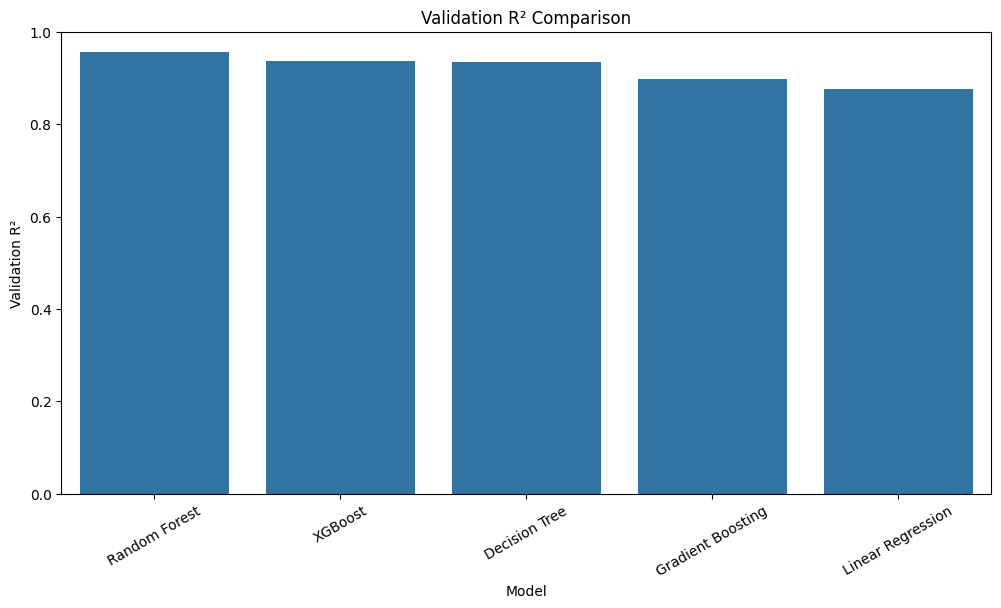

In [144]:
#رVisualize Validation Performance

plt.figure(figsize=(12, 6))

sns.barplot(
    data=results_df,
    x="Model",
    y="Validation R²"
)

plt.title("Validation R² Comparison")
plt.xlabel("Model")
plt.ylabel("Validation R²")
plt.xticks(rotation=30)
plt.ylim(0, 1)
plt.show()

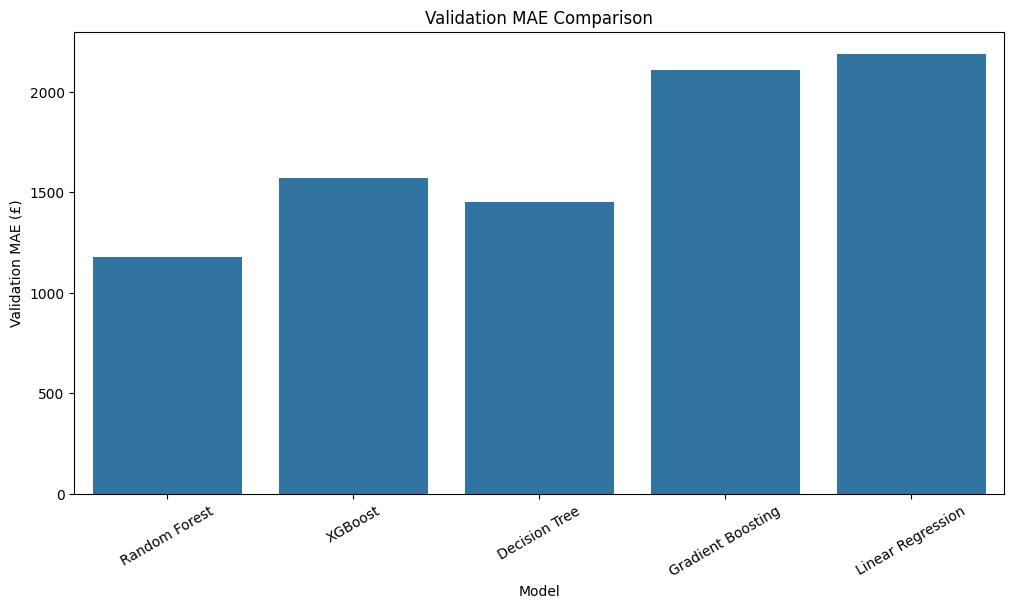

In [145]:
# Compare Validation MAE

plt.figure(figsize=(12, 6))

sns.barplot(
    data=results_df,
    x="Model",
    y="Validation MAE"
)

plt.title("Validation MAE Comparison")
plt.xlabel("Model")
plt.ylabel("Validation MAE (£)")
plt.xticks(rotation=30)
plt.show()

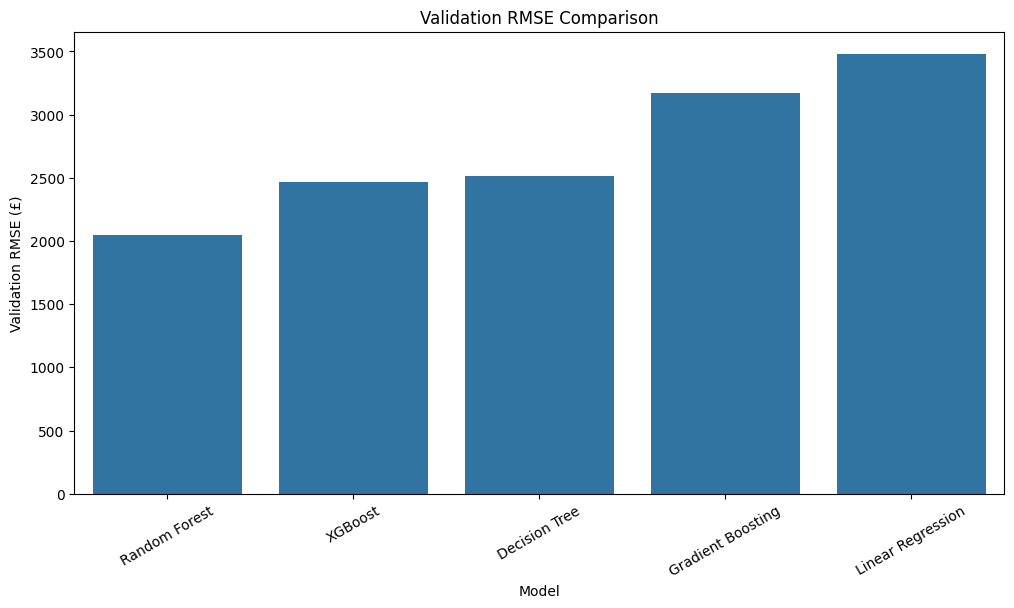

In [146]:
# Compare Validation RMSE

plt.figure(figsize=(12, 6))

sns.barplot(
    data=results_df,
    x="Model",
    y="Validation RMSE"
)

plt.title("Validation RMSE Comparison")
plt.xlabel("Model")
plt.ylabel("Validation RMSE (£)")
plt.xticks(rotation=30)
plt.show()

In [147]:
# Calculate the Overfitting Gap

results_df["R² Gap"] = (
    results_df["Train R²"] -
    results_df["Validation R²"]
)

results_df["MAE Gap"] = (
    results_df["Validation MAE"] -
    results_df["Train MAE"]
)

results_df["RMSE Gap"] = (
    results_df["Validation RMSE"] -
    results_df["Train RMSE"]
)

display(
    results_df[[
        "Model",
        "Train R²",
        "Validation R²",
        "R² Gap",
        "Train MAE",
        "Validation MAE",
        "MAE Gap",
        "Train RMSE",
        "Validation RMSE",
        "RMSE Gap"
    ]].style.format({
        "Train R²": "{:.4f}",
        "Validation R²": "{:.4f}",
        "R² Gap": "{:.4f}",
        "Train MAE": "£{:,.2f}",
        "Validation MAE": "£{:,.2f}",
        "MAE Gap": "£{:,.2f}",
        "Train RMSE": "£{:,.2f}",
        "Validation RMSE": "£{:,.2f}",
        "RMSE Gap": "£{:,.2f}"
    })
)

,Model,Train R²,Validation R²,R² Gap,Train MAE,Validation MAE,MAE Gap,Train RMSE,Validation RMSE,RMSE Gap
0,Random Forest,0.9937,0.9569,0.0368,£448.71,"£1,175.65",£726.94,£774.87,"£2,048.15","£1,273.28"
1,XGBoost,0.9467,0.9374,0.0094,"£1,526.25","£1,569.29",£43.04,"£2,252.57","£2,468.80",£216.23
2,Decision Tree,0.9995,0.9349,0.0646,£20.80,"£1,453.62","£1,432.82",£207.50,"£2,516.55","£2,309.04"
3,Gradient Boosting,0.9023,0.8966,0.0056,"£2,079.69","£2,108.96",£29.27,"£3,051.94","£3,172.03",£120.10
4,Linear Regression,0.8685,0.8754,-0.0069,"£2,216.67","£2,188.83",£-27.84,"£3,540.22","£3,482.08",£-58.14


In [148]:
# Save Validation Predictions

validation_predictions = {}

for name, model in trained_models.items():
    validation_predictions[name] = model.predict(
        X_val_processed
    )

print("Validation predictions stored for:")
for name in validation_predictions:
    print("-", name)

Validation predictions stored for:
- Linear Regression
- Decision Tree
- Random Forest
- Gradient Boosting
- XGBoost


## Model Comparison

Random Forest achieved the strongest validation performance with an R² of **0.9569**, MAE of **£1,175.65**, and RMSE of **£2,048.15**.

XGBoost and Decision Tree also performed well, while Gradient Boosting and Linear Regression achieved lower validation R² values.

Decision Tree showed the largest train-validation gap, while Random Forest showed a smaller gap. These results supported selecting Random Forest for further tuning.


## Hyperparameter Tuning

Random Forest was selected for further improvement based on its validation performance.

`RandomizedSearchCV` was used to explore different Random Forest hyperparameter combinations using 3-fold cross-validation.

The tuned model was compared with the original Random Forest using training and validation performance.


In [149]:
# Define the Search Space

from sklearn.model_selection import RandomizedSearchCV

rf = trained_models["Random Forest"]

param_distributions = {
    "n_estimators": [100, 150, 200],
    "max_depth": [None, 20, 30, 40],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", 0.5, 0.8]
}

print("Number of possible parameter combinations:")

total_combinations = (
    len(param_distributions["n_estimators"])
    * len(param_distributions["max_depth"])
    * len(param_distributions["min_samples_split"])
    * len(param_distributions["min_samples_leaf"])
    * len(param_distributions["max_features"])
)

print(total_combinations)

Number of possible parameter combinations:
324


In [150]:
# Randomized Search

import time

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_distributions,
    n_iter=6,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1,
    verbose=2
)

start_time = time.time()

random_search.fit(
    X_train_processed,
    y_train
)

tuning_time = time.time() - start_time

print(f"\nRandomizedSearchCV completed in {tuning_time / 60:.2f} minutes")

Fitting 3 folds for each of 6 candidates, totalling 18 fits


/usr/local/lib/python3.13/dist-packages/joblib/externals/loky/process_executor.py:787: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



RandomizedSearchCV completed in 61.66 minutes


In [151]:
# Best Parameters

print("Best parameters:")
print(random_search.best_params_)

print("\nBest CV RMSE:")
print(-random_search.best_score_)

Best parameters:
{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 20}

Best CV RMSE:
2096.2739576212857


In [152]:
# Get the Tuned Model

tuned_rf = random_search.best_estimator_

print(tuned_rf)

RandomForestRegressor(max_depth=20, max_features=0.5, n_jobs=-1,
                      random_state=42)


In [153]:
# Evaluate Tuned Random Forest

# Predictions from tuned model
y_train_pred_tuned = tuned_rf.predict(X_train_processed)
y_val_pred_tuned = tuned_rf.predict(X_val_processed)

# Training metrics
tuned_train_r2 = r2_score(y_train, y_train_pred_tuned)
tuned_train_mae = mean_absolute_error(y_train, y_train_pred_tuned)
tuned_train_rmse = np.sqrt(
    mean_squared_error(y_train, y_train_pred_tuned)
)

# Validation metrics
tuned_val_r2 = r2_score(y_val, y_val_pred_tuned)
tuned_val_mae = mean_absolute_error(y_val, y_val_pred_tuned)
tuned_val_rmse = np.sqrt(
    mean_squared_error(y_val, y_val_pred_tuned)
)

print("Tuned Random Forest Results")
print("-" * 40)

print(f"Train R²:       {tuned_train_r2:.4f}")
print(f"Validation R²:  {tuned_val_r2:.4f}")

print(f"Train MAE:      £{tuned_train_mae:,.2f}")
print(f"Validation MAE: £{tuned_val_mae:,.2f}")

print(f"Train RMSE:      £{tuned_train_rmse:,.2f}")
print(f"Validation RMSE: £{tuned_val_rmse:,.2f}")

Tuned Random Forest Results
----------------------------------------
Train R²:       0.9862
Validation R²:  0.9578
Train MAE:      £741.92
Validation MAE: £1,173.53
Train RMSE:      £1,145.04
Validation RMSE: £2,026.45


In [154]:
# Before vs After Tuning

before_after = pd.DataFrame({
    "Metric": [
        "Train R²",
        "Validation R²",
        "Train MAE",
        "Validation MAE",
        "Train RMSE",
        "Validation RMSE"
    ],
    "Original Random Forest": [
        results_df.loc[
            results_df["Model"] == "Random Forest",
            "Train R²"
        ].iloc[0],

        results_df.loc[
            results_df["Model"] == "Random Forest",
            "Validation R²"
        ].iloc[0],

        results_df.loc[
            results_df["Model"] == "Random Forest",
            "Train MAE"
        ].iloc[0],

        results_df.loc[
            results_df["Model"] == "Random Forest",
            "Validation MAE"
        ].iloc[0],

        results_df.loc[
            results_df["Model"] == "Random Forest",
            "Train RMSE"
        ].iloc[0],

        results_df.loc[
            results_df["Model"] == "Random Forest",
            "Validation RMSE"
        ].iloc[0]
    ],
    "Tuned Random Forest": [
        tuned_train_r2,
        tuned_val_r2,
        tuned_train_mae,
        tuned_val_mae,
        tuned_train_rmse,
        tuned_val_rmse
    ]
})

display(
    before_after.style.format({
        "Original Random Forest": "{:.4f}",
        "Tuned Random Forest": "{:.4f}"
    })
)

,Metric,Original Random Forest,Tuned Random Forest
0,Train R²,0.9937,0.9862
1,Validation R²,0.9569,0.9578
2,Train MAE,448.7120,741.9234
3,Validation MAE,1175.6509,1173.5316
4,Train RMSE,774.8670,1145.0350
5,Validation RMSE,2048.1491,2026.4496


In [155]:
# Calculate Tuning Improvement

original_val_r2 = results_df.loc[
    results_df["Model"] == "Random Forest",
    "Validation R²"
].iloc[0]

original_val_mae = results_df.loc[
    results_df["Model"] == "Random Forest",
    "Validation MAE"
].iloc[0]

original_val_rmse = results_df.loc[
    results_df["Model"] == "Random Forest",
    "Validation RMSE"
].iloc[0]

print("Change after tuning:")
print("-" * 40)

print(
    f"Validation R² change: "
    f"{tuned_val_r2 - original_val_r2:+.4f}"
)

print(
    f"Validation MAE change: "
    f"£{tuned_val_mae - original_val_mae:+,.2f}"
)

print(
    f"Validation RMSE change: "
    f"£{tuned_val_rmse - original_val_rmse:+,.2f}"
)

Change after tuning:
----------------------------------------
Validation R² change: +0.0009
Validation MAE change: £-2.12
Validation RMSE change: £-21.70


### Tuning Results

`RandomizedSearchCV` evaluated 6 parameter combinations using 3-fold cross-validation.

The tuned Random Forest achieved:

* **Validation R²:** 0.9578
* **Validation MAE:** £1,173.53
* **Validation RMSE:** £2,026.45

Compared with the original model, the improvement was small but positive, while the training R² decreased from 0.9937 to 0.9862.

The tuned Random Forest was therefore retained for final test evaluation.


## Final Model Evaluation

In [156]:
# Final predictions on the untouched test set
y_test_pred = tuned_rf.predict(X_test_processed)

print("Final test predictions generated.")
print("Number of predictions:", len(y_test_pred))

Final test predictions generated.
Number of predictions: 15940


In [157]:
# Calculate Final Test Metrics

final_test_r2 = r2_score(y_test, y_test_pred)

final_test_mae = mean_absolute_error(
    y_test,
    y_test_pred
)

final_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_test_pred
    )
)

print("Final Model - Test Set Performance")
print("=" * 45)

print(f"R²:   {final_test_r2:.4f}")
print(f"MAE:  £{final_test_mae:,.2f}")
print(f"RMSE: £{final_test_rmse:,.2f}")

Final Model - Test Set Performance
R²:   0.9652
MAE:  £1,164.69
RMSE: £1,823.59


In [158]:
# Compare Validation vs Final Test

final_comparison = pd.DataFrame({
    "Metric": [
        "R²",
        "MAE",
        "RMSE"
    ],
    "Validation": [
        tuned_val_r2,
        tuned_val_mae,
        tuned_val_rmse
    ],
    "Test": [
        final_test_r2,
        final_test_mae,
        final_test_rmse
    ]
})

display(
    final_comparison.style.format({
        "Validation": "{:.4f}",
        "Test": "{:.4f}"
    })
)

,Metric,Validation,Test
0,R²,0.9578,0.9652
1,MAE,1173.5316,1164.6932
2,RMSE,2026.4496,1823.5919


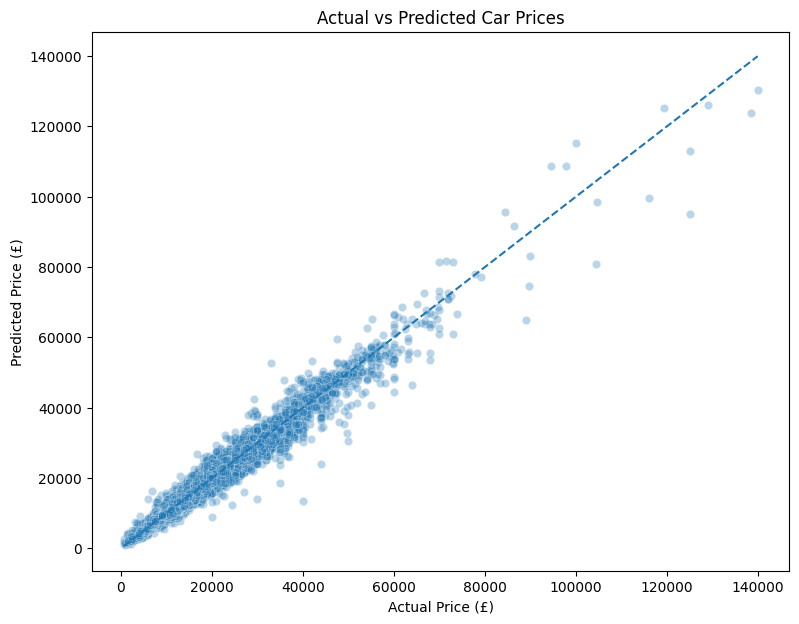

In [159]:
# Test Set: Actual vs Predicted

plt.figure(figsize=(9, 7))

sns.scatterplot(
    x=y_test,
    y=y_test_pred,
    alpha=0.3
)

# Perfect prediction line
min_price = min(y_test.min(), y_test_pred.min())
max_price = max(y_test.max(), y_test_pred.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

plt.title("Actual vs Predicted Car Prices")
plt.xlabel("Actual Price (£)")
plt.ylabel("Predicted Price (£)")

plt.show()

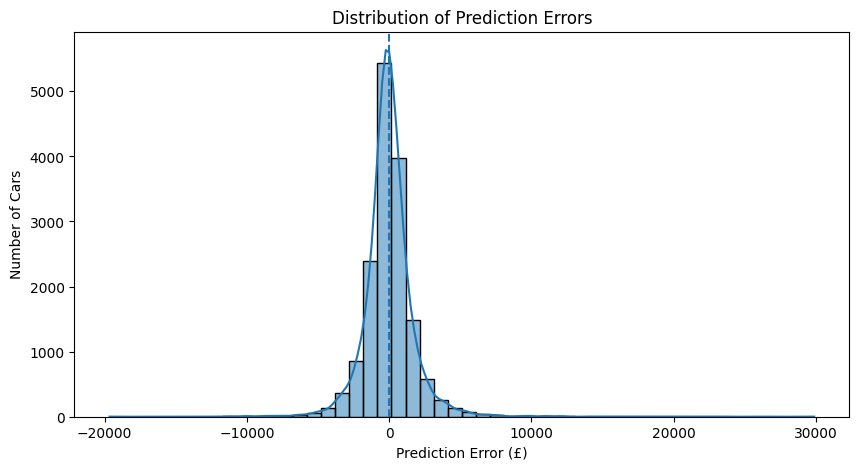

In [160]:
# Prediction Error Distribution

test_errors = y_test - y_test_pred

plt.figure(figsize=(10, 5))

sns.histplot(
    test_errors,
    bins=50,
    kde=True
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title("Distribution of Prediction Errors")
plt.xlabel("Prediction Error (£)")
plt.ylabel("Number of Cars")

plt.show()

In [161]:
# Calculate Absolute Errors

test_results = X_test.copy()

test_results["Actual Price"] = y_test.values
test_results["Predicted Price"] = y_test_pred

test_results["Error"] = (
    test_results["Actual Price"] -
    test_results["Predicted Price"]
)

test_results["Absolute Error"] = (
    test_results["Error"].abs()
)

test_results["Percentage Error"] = (
    test_results["Absolute Error"] /
    test_results["Actual Price"]
) * 100

test_results.head()

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,Make,Actual Price,Predicted Price,Error,Absolute Error,Percentage Error
62271,C Class,2019,Semi-Auto,3689,Diesel,NaN,NaN,1.6,Mercedes,27000,27097.181433,-97.181433,97.181433,0.359931
3957,A4,2016,Semi-Auto,68441,Diesel,0.0,72.4,2.0,Audi,11790,12793.776247,-1003.776247,1003.776247,8.513793
6552,A5,2017,Semi-Auto,45029,Diesel,30.0,65.7,2.0,Audi,19225,18626.471467,598.528533,598.528533,3.113282
20772,4 Series,2015,Automatic,76660,Diesel,125.0,57.6,2.0,BMW,14000,12829.792202,1170.207798,1170.207798,8.358627
70550,Fabia,2017,Manual,25985,Petrol,150.0,64.2,1.0,Skoda,7559,9262.259088,-1703.259088,1703.259088,22.532863


In [162]:
# Largest Prediction Errors

largest_errors = test_results.sort_values(
    by="Absolute Error",
    ascending=False
).head(10)

display(
    largest_errors[
        [
            "Make",
            "model",
            "year",
            "mileage",
            "transmission",
            "fuelType",
            "engineSize",
            "Actual Price",
            "Predicted Price",
            "Error",
            "Absolute Error",
            "Percentage Error"
        ]
    ].style.format({
        "Actual Price": "£{:,.2f}",
        "Predicted Price": "£{:,.2f}",
        "Error": "£{:,.2f}",
        "Absolute Error": "£{:,.2f}",
        "Percentage Error": "{:.2f}%"
    })
)

,Make,model,year,mileage,transmission,fuelType,engineSize,Actual Price,Predicted Price,Error,Absolute Error,Percentage Error
3342,Audi,R8,2019,100,Automatic,Petrol,5.200000,"£125,000.00","£95,112.32","£29,887.68","£29,887.68",23.91%
20429,BMW,X5,2016,49000,Automatic,Petrol,nan,"£39,948.00","£13,351.87","£26,596.13","£26,596.13",66.58%
64134,Mercedes,C Class,2019,200,Semi-Auto,Petrol,4.000000,"£88,995.00","£64,972.16","£24,022.84","£24,022.84",26.99%
52729,Mercedes,S Class,2018,3796,Semi-Auto,Petrol,4.000000,"£104,400.00","£80,927.29","£23,472.71","£23,472.71",22.48%
104553,Volkswagen,Caravelle,2019,12152,Automatic,Diesel,2.000000,"£43,990.00","£24,076.68","£19,913.32","£19,913.32",45.27%
28366,Ford,Mustang,2017,12000,Automatic,Petrol,5.000000,"£32,990.00","£52,637.54","£-19,647.54","£19,647.54",59.56%
33011,Ford,Mustang,2017,21575,Manual,Petrol,5.000000,"£49,999.00","£30,433.60","£19,565.40","£19,565.40",39.13%
57917,Mercedes,E Class,2018,28300,Automatic,Petrol,4.000000,"£63,990.00","£46,321.10","£17,668.90","£17,668.90",27.61%
7441,Audi,Q5,2020,1500,Automatic,Petrol,nan,"£49,790.00","£32,765.71","£17,024.29","£17,024.29",34.19%
5638,Audi,R8,2019,2369,Automatic,Petrol,5.200000,"£116,000.00","£99,559.48","£16,440.52","£16,440.52",14.17%


The final model achieved:

- **R²: 0.9652**
- **MAE: £1,164.69**
- **RMSE: £1,823.59**

## Model Understanding

In [163]:
# Get Feature Names

feature_names = preprocessor.get_feature_names_out()

print("Number of processed features:", len(feature_names))
print("\nFirst 20 feature names:")
print(feature_names[:20])

Number of processed features: 216

First 20 feature names:
['num__year' 'num__mileage' 'num__tax' 'num__mpg' 'num__engineSize'
 'num__car_age' 'num__mileage_per_year' 'num__engine_mpg_ratio'
 'cat__model_ 1 Series' 'cat__model_ 2 Series' 'cat__model_ 3 Series'
 'cat__model_ 4 Series' 'cat__model_ 5 Series' 'cat__model_ 6 Series'
 'cat__model_ 7 Series' 'cat__model_ 8 Series' 'cat__model_ A Class'
 'cat__model_ A1' 'cat__model_ A3' 'cat__model_ A4']


In [164]:
# Extract Feature Importance

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": tuned_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

feature_importance.head(20)

,Feature,Importance
0,num__engine_mpg_ratio,0.232294
1,num__engineSize,0.167126
2,cat__transmission_Manual,0.155735
3,num__car_age,0.111860
4,num__year,0.105186
5,num__mileage,0.062326
6,num__mpg,0.032132
7,num__mileage_per_year,0.014234
8,cat__Make_Mercedes,0.012423
9,num__tax,0.012332


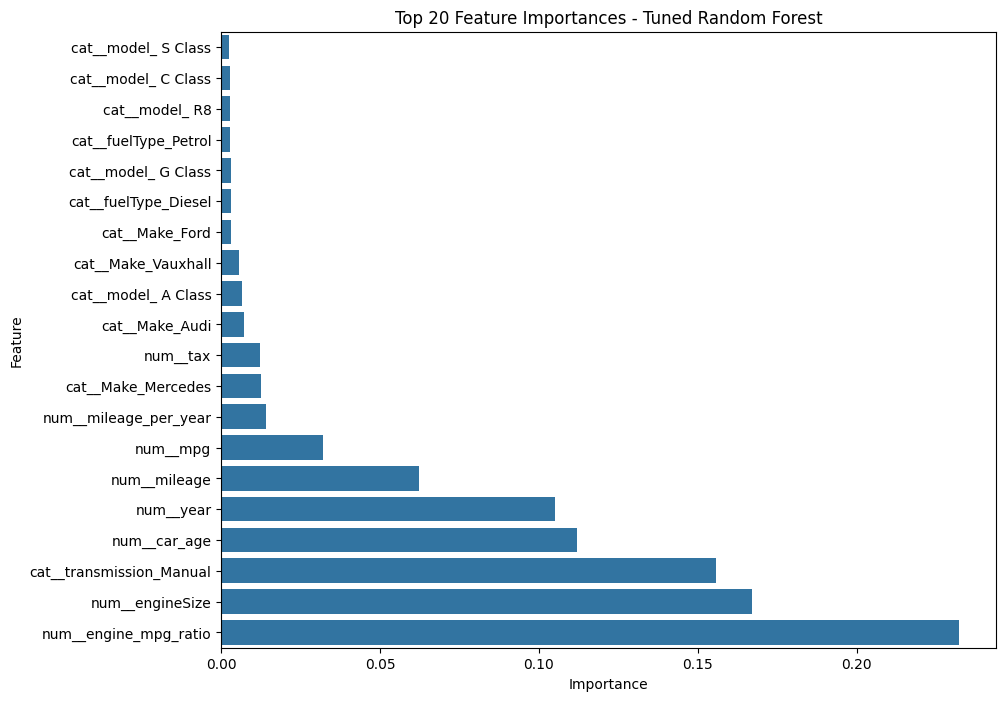

In [165]:
# Visualize Top 20 Features

top_features = feature_importance.head(20).sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(10, 8))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Feature Importances - Tuned Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [166]:
# Group One-Hot Features by Original Feature

def get_original_feature(feature_name):
    if feature_name.startswith("num__"):
        return feature_name.replace("num__", "")

    if feature_name.startswith("cat__"):
        categorical_name = feature_name.replace("cat__", "")

        for col in categorical_features:
            if categorical_name.startswith(col + "_"):
                return col

        return categorical_name

    return feature_name


feature_importance["Original Feature"] = (
    feature_importance["Feature"]
    .apply(get_original_feature)
)

grouped_importance = (
    feature_importance
    .groupby("Original Feature")["Importance"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

grouped_importance

,Original Feature,Importance
0,engine_mpg_ratio,0.232294
1,engineSize,0.167126
2,transmission,0.159014
3,car_age,0.111860
4,year,0.105186
5,mileage,0.062326
6,model,0.062133
7,Make,0.034767
8,mpg,0.032132
9,mileage_per_year,0.014234


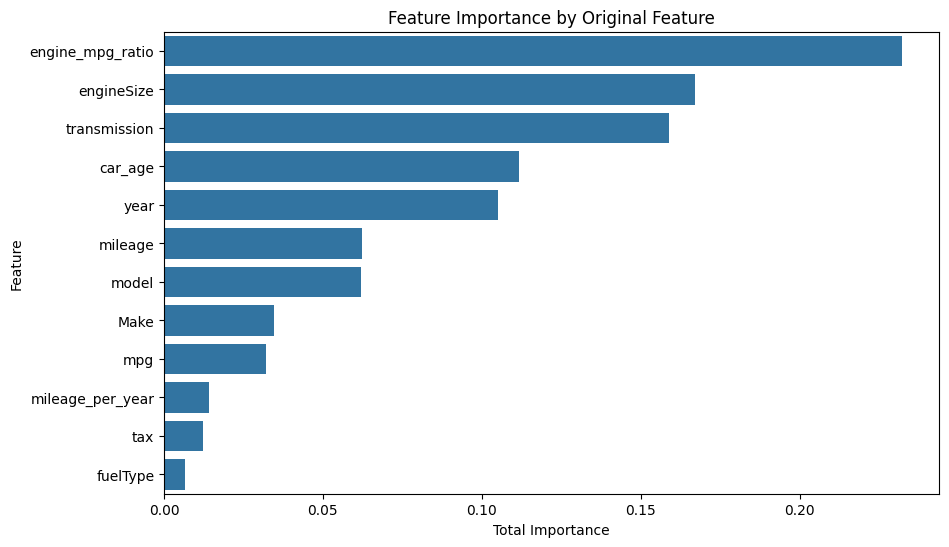

In [167]:
# Plot Original Feature Importance

plt.figure(figsize=(10, 6))

sns.barplot(
    data=grouped_importance,
    x="Importance",
    y="Original Feature"
)

plt.title("Feature Importance by Original Feature")
plt.xlabel("Total Importance")
plt.ylabel("Feature")

plt.show()

In [168]:
# Display the Largest Errors

largest_errors = (
    test_results
    .sort_values(
        by="Absolute Error",
        ascending=False
    )
    .head(10)
)

display(
    largest_errors[
        [
            "Make",
            "model",
            "year",
            "mileage",
            "transmission",
            "fuelType",
            "engineSize",
            "Actual Price",
            "Predicted Price",
            "Error",
            "Absolute Error",
            "Percentage Error"
        ]
    ].style.format({
        "Actual Price": "£{:,.2f}",
        "Predicted Price": "£{:,.2f}",
        "Error": "£{:,.2f}",
        "Absolute Error": "£{:,.2f}",
        "Percentage Error": "{:.2f}%"
    })
)

,Make,model,year,mileage,transmission,fuelType,engineSize,Actual Price,Predicted Price,Error,Absolute Error,Percentage Error
3342,Audi,R8,2019,100,Automatic,Petrol,5.200000,"£125,000.00","£95,112.32","£29,887.68","£29,887.68",23.91%
20429,BMW,X5,2016,49000,Automatic,Petrol,nan,"£39,948.00","£13,351.87","£26,596.13","£26,596.13",66.58%
64134,Mercedes,C Class,2019,200,Semi-Auto,Petrol,4.000000,"£88,995.00","£64,972.16","£24,022.84","£24,022.84",26.99%
52729,Mercedes,S Class,2018,3796,Semi-Auto,Petrol,4.000000,"£104,400.00","£80,927.29","£23,472.71","£23,472.71",22.48%
104553,Volkswagen,Caravelle,2019,12152,Automatic,Diesel,2.000000,"£43,990.00","£24,076.68","£19,913.32","£19,913.32",45.27%
28366,Ford,Mustang,2017,12000,Automatic,Petrol,5.000000,"£32,990.00","£52,637.54","£-19,647.54","£19,647.54",59.56%
33011,Ford,Mustang,2017,21575,Manual,Petrol,5.000000,"£49,999.00","£30,433.60","£19,565.40","£19,565.40",39.13%
57917,Mercedes,E Class,2018,28300,Automatic,Petrol,4.000000,"£63,990.00","£46,321.10","£17,668.90","£17,668.90",27.61%
7441,Audi,Q5,2020,1500,Automatic,Petrol,nan,"£49,790.00","£32,765.71","£17,024.29","£17,024.29",34.19%
5638,Audi,R8,2019,2369,Automatic,Petrol,5.200000,"£116,000.00","£99,559.48","£16,440.52","£16,440.52",14.17%


### Feature Importance

Feature importance from the tuned Random Forest was examined to identify which features contributed most to the model's predictions.

The most important features included `engine_mpg_ratio`, `engineSize`, `transmission`, `car_age`, and `year`.

These values represent relative predictive importance and should not be interpreted as causal effects.


### Large Prediction Error Investigation

The largest errors were mainly observed for high-priced or less common vehicles.

For example, an Audi R8 with an actual price of £125,000 was predicted at approximately £95,112, while one Ford Mustang was over-predicted.

These errors may occur because rare and high-value vehicles are less represented in the dataset and may have pricing factors not captured by the available features.


## Smart Deal Advisor

In [169]:
# Deal Classification Function

def classify_deal(predicted_price, seller_price):
    """
    Classify a car deal by comparing the seller's price
    with the model's predicted market price.
    """

    difference_percent = (
        (seller_price - predicted_price)
        / predicted_price
    ) * 100

    if difference_percent < -10:
        rating = "Great Deal"

    elif difference_percent < -5:
        rating = "Good Deal"

    elif difference_percent <= 5:
        rating = "Fair Price"

    elif difference_percent <= 10:
        rating = "Slightly Overpriced"

    else:
        rating = "Overpriced"

    return difference_percent, rating

In [170]:
# Test the Deal Advisor

test_deals = [
    (20000, 17000),
    (20000, 18500),
    (20000, 20000),
    (20000, 21000),
    (20000, 23000)
]

for predicted_price, seller_price in test_deals:

    difference, rating = classify_deal(
        predicted_price,
        seller_price
    )

    print(
        f"Market Price: £{predicted_price:,.0f} | "
        f"Seller Price: £{seller_price:,.0f} | "
        f"Difference: {difference:+.2f}% | "
        f"Rating: {rating}"
    )

Market Price: £20,000 | Seller Price: £17,000 | Difference: -15.00% | Rating: Great Deal
Market Price: £20,000 | Seller Price: £18,500 | Difference: -7.50% | Rating: Good Deal
Market Price: £20,000 | Seller Price: £20,000 | Difference: +0.00% | Rating: Fair Price
Market Price: £20,000 | Seller Price: £21,000 | Difference: +5.00% | Rating: Fair Price
Market Price: £20,000 | Seller Price: £23,000 | Difference: +15.00% | Rating: Overpriced


In [171]:
# Deal Advisor Function with Full Output

def deal_advisor(predicted_price, seller_price):

    difference = seller_price - predicted_price

    difference_percent = (
        difference / predicted_price
    ) * 100

    if difference_percent < -10:
        rating = "Great Deal"

    elif difference_percent < -5:
        rating = "Good Deal"

    elif difference_percent <= 5:
        rating = "Fair Price"

    elif difference_percent <= 10:
        rating = "Slightly Overpriced"

    else:
        rating = "Overpriced"

    return {
        "Predicted Market Price": predicted_price,
        "Seller Price": seller_price,
        "Difference": difference,
        "Difference %": difference_percent,
        "Deal Rating": rating
    }

In [172]:
# Example

example_deal = deal_advisor(
    predicted_price=25000,
    seller_price=22000
)

example_deal

{'Predicted Market Price': 25000,
 'Seller Price': 22000,
 'Difference': -3000,
 'Difference %': -12.0,
 'Deal Rating': 'Great Deal'}

In [173]:
# Create a More Realistic Example Using a Test Car

example_index = test_results["Absolute Error"].idxmin()

example_car = test_results.loc[example_index]

predicted_market_price = example_car["Predicted Price"]

seller_price = 22000

deal_result = deal_advisor(
    predicted_market_price,
    seller_price
)

print(f"Make: {example_car['Make']}")
print(f"Model: {example_car['model']}")
print(f"Year: {example_car['year']}")
print(f"Predicted Market Price: £{predicted_market_price:,.2f}")
print(f"Seller Price: £{seller_price:,.2f}")
print(f"Difference: £{deal_result['Difference']:,.2f}")
print(f"Difference %: {deal_result['Difference %']:+.2f}%")
print(f"Deal Rating: {deal_result['Deal Rating']}")

Make: Hyundai
Model:  Ioniq
Year: 2018
Predicted Market Price: £16,698.09
Seller Price: £22,000.00
Difference: £5,301.91
Difference %: +31.75%
Deal Rating: Overpriced


The Smart Deal Advisor compares the predicted market price with the seller's asking price and calculates the percentage difference.

The classification rules are:

* More than 10% below → **Great Deal**
* 5% to 10% below → **Good Deal**
* Within ±5% → **Fair Price**
* 5% to 10% above → **Slightly Overpriced**
* More than 10% above → **Overpriced**

The advisor provides a data-driven comparison based on the model's estimated market price.


### Smart Deal Advisor Example

For a 2018 Hyundai Ioniq, the model estimated a market price of approximately **£16,698.09**.

With a seller price of **£22,000**, the asking price was **31.75% higher** than the predicted market price and was therefore classified as **Overpriced**.

This demonstrates how the prediction model can be extended into a simple deal-comparison tool.


## Final Prediction Pipeline

In [174]:
# Prediction Function

def predict_car_price(
    make,
    model,
    year,
    mileage,
    transmission,
    fuel_type,
    engine_size,
    tax=np.nan,
    mpg=np.nan
):
    """
    Predict the market price of a used car using the trained model.
    """

    # Create a DataFrame containing the new car information
    input_data = pd.DataFrame([{
        "model": model,
        "year": year,
        "mileage": mileage,
        "transmission": transmission,
        "fuelType": fuel_type,
        "tax": tax,
        "mpg": mpg,
        "engineSize": engine_size,
        "Make": make
    }])

    # Apply the same feature engineering used during training
    input_data_fe = create_features(input_data)

    # Apply the fitted preprocessing pipeline
    input_processed = preprocessor.transform(input_data_fe)

    # Predict the market price
    predicted_price = tuned_rf.predict(input_processed)[0]

    return predicted_price

In [175]:
# Test with a New Car

predicted_price = predict_car_price(
    make="Hyundai",
    model=" Ioniq",
    year=2018,
    mileage=30000,
    transmission="Automatic",
    fuel_type="Hybrid",
    engine_size=1.6
)

print(f"Predicted Market Price: £{predicted_price:,.2f}")

Predicted Market Price: £15,682.47


In [176]:
# Combine Prediction + Deal Advisor

def car_price_and_deal_advisor(
    make,
    model,
    year,
    mileage,
    transmission,
    fuel_type,
    engine_size,
    seller_price,
    tax=np.nan,
    mpg=np.nan
):
    """
    Predict the market price and classify the seller's asking price.
    """

    predicted_price = predict_car_price(
        make=make,
        model=model,
        year=year,
        mileage=mileage,
        transmission=transmission,
        fuel_type=fuel_type,
        engine_size=engine_size,
        tax=tax,
        mpg=mpg
    )

    deal_result = deal_advisor(
        predicted_price=predicted_price,
        seller_price=seller_price
    )

    return {
        "Make": make,
        "Model": model,
        "Year": year,
        "Predicted Market Price": predicted_price,
        "Seller Price": seller_price,
        "Difference": deal_result["Difference"],
        "Difference %": deal_result["Difference %"],
        "Deal Rating": deal_result["Deal Rating"]
    }

In [177]:
# Full Test

result = car_price_and_deal_advisor(
    make="Hyundai",
    model=" Ioniq",
    year=2018,
    mileage=30000,
    transmission="Automatic",
    fuel_type="Hybrid",
    engine_size=1.6,
    seller_price=15000
)

for key, value in result.items():

    if isinstance(value, (int, float, np.integer, np.floating)):

        if "Price" in key or key == "Difference":
            print(f"{key}: £{value:,.2f}")

        elif "%" in key:
            print(f"{key}: {value:+.2f}%")

        else:
            print(f"{key}: {value}")

    else:
        print(f"{key}: {value}")

Make: Hyundai
Model:  Ioniq
Year: 2018
Predicted Market Price: £15,682.47
Seller Price: £15,000.00
Difference: £-682.47
Difference %: -4.35%
Deal Rating: Fair Price


In [178]:
# Save the Model for Deployment

import joblib

joblib.dump(tuned_rf, "tuned_random_forest.pkl")
joblib.dump(preprocessor, "preprocessor.pkl")

print("Model and preprocessor saved successfully.")

Model and preprocessor saved successfully.


In [179]:
# Save the Feature Engineering Settings

deployment_config = {
    "reference_year": REFERENCE_YEAR,
    "make_options": sorted(df_clean["Make"].unique().tolist()),
    "model_options": sorted(df_clean["model"].unique().tolist()),
    "transmission_options": sorted(df_clean["transmission"].unique().tolist()),
    "fuel_type_options": sorted(df_clean["fuelType"].unique().tolist())
}

joblib.dump(deployment_config, "deployment_config.pkl")

print("Deployment configuration saved successfully.")

Deployment configuration saved successfully.


In [180]:
# Verify Saved Files

import os

files_to_check = [
    "tuned_random_forest.pkl",
    "preprocessor.pkl",
    "deployment_config.pkl"
]

for file in files_to_check:
    print(f"{file}: {'Found' if os.path.exists(file) else 'Missing'}")

tuned_random_forest.pkl: Found
preprocessor.pkl: Found
deployment_config.pkl: Found


## Streamlit App

In [181]:
import os
import shutil

os.makedirs("autoworth_app", exist_ok=True)

files_to_copy = [
    "tuned_random_forest.pkl",
    "preprocessor.pkl",
    "deployment_config.pkl"
]

for file in files_to_copy:
    shutil.copy(file, "autoworth_app")

print("Deployment files copied successfully:")
for file in files_to_copy:
    print("✓", file)

Deployment files copied successfully:
✓ tuned_random_forest.pkl
✓ preprocessor.pkl
✓ deployment_config.pkl


In [182]:
app_code = r'''
import streamlit as st
import pandas as pd
import numpy as np
import joblib


# ============================================================
# Page Configuration
# ============================================================

st.set_page_config(
    page_title="AutoWorth AI",
    page_icon="🚗",
    layout="centered"
)


# ============================================================
# Load Model and Configuration
# ============================================================

model = joblib.load("tuned_random_forest.pkl")
preprocessor = joblib.load("preprocessor.pkl")
config = joblib.load("deployment_config.pkl")

REFERENCE_YEAR = config["reference_year"]

make_options = config["make_options"]
model_options = config["model_options"]
transmission_options = config["transmission_options"]
fuel_type_options = config["fuel_type_options"]


# ============================================================
# Feature Engineering
# ============================================================

def create_features(data):

    data = data.copy()

    data["car_age"] = REFERENCE_YEAR - data["year"]

    data["mileage_per_year"] = (
        data["mileage"] / data["car_age"]
    )

    data["engine_mpg_ratio"] = (
        data["engineSize"] / data["mpg"]
    )

    return data


# ============================================================
# Deal Advisor
# ============================================================

def deal_advisor(predicted_price, seller_price):

    difference = seller_price - predicted_price

    difference_percent = (
        difference / predicted_price
    ) * 100

    if difference_percent < -10:
        rating = "Great Deal"

    elif difference_percent < -5:
        rating = "Good Deal"

    elif difference_percent <= 5:
        rating = "Fair Price"

    elif difference_percent <= 10:
        rating = "Slightly Overpriced"

    else:
        rating = "Overpriced"

    return difference, difference_percent, rating


# ============================================================
# App Header
# ============================================================

st.title("🚗 AutoWorth AI")

st.subheader("Used Car Price & Deal Advisor")

st.write(
    "Enter the vehicle details below to estimate its market price "
    "and compare it with the seller's asking price."
)


# ============================================================
# User Inputs
# ============================================================

st.markdown("### Vehicle Information")

make = st.selectbox(
    "Make",
    make_options
)

car_model = st.selectbox(
    "Model",
    model_options
)

year = st.number_input(
    "Year",
    min_value=1991,
    max_value=2020,
    value=2018,
    step=1
)

mileage = st.number_input(
    "Mileage",
    min_value=0,
    max_value=500000,
    value=30000,
    step=100
)

transmission = st.selectbox(
    "Transmission",
    transmission_options
)

fuel_type = st.selectbox(
    "Fuel Type",
    fuel_type_options
)

engine_size = st.number_input(
    "Engine Size",
    min_value=0.1,
    max_value=7.0,
    value=1.6,
    step=0.1
)

seller_price = st.number_input(
    "Seller Price (£)",
    min_value=100,
    max_value=200000,
    value=15000,
    step=100
)


# ============================================================
# Prediction
# ============================================================

if st.button("Estimate Price & Check Deal", type="primary"):

    # Create input DataFrame
    input_data = pd.DataFrame([{
        "model": car_model,
        "year": year,
        "mileage": mileage,
        "transmission": transmission,
        "fuelType": fuel_type,
        "tax": np.nan,
        "mpg": np.nan,
        "engineSize": engine_size,
        "Make": make
    }])

    # Feature engineering
    input_data_fe = create_features(input_data)

    # Preprocessing
    input_processed = preprocessor.transform(input_data_fe)

    # Prediction
    predicted_price = model.predict(input_processed)[0]

    # Deal analysis
    difference, difference_percent, rating = deal_advisor(
        predicted_price,
        seller_price
    )


    # ========================================================
    # Results
    # ========================================================

    st.markdown("---")
    st.markdown("### 💰 Price Estimate")

    col1, col2 = st.columns(2)

    with col1:
        st.metric(
            "Estimated Market Price",
            f"£{predicted_price:,.2f}"
        )

    with col2:
        st.metric(
            "Seller Price",
            f"£{seller_price:,.2f}"
        )


    st.markdown("### 📊 Deal Analysis")

    col1, col2 = st.columns(2)

    with col1:
        st.metric(
            "Difference",
            f"£{difference:,.2f}"
        )

    with col2:
        st.metric(
            "Difference %",
            f"{difference_percent:+.2f}%"
        )


    st.markdown("### 🏷️ Deal Rating")

    if rating == "Great Deal":
        st.success(f"**{rating}**")

    elif rating == "Good Deal":
        st.success(f"**{rating}**")

    elif rating == "Fair Price":
        st.info(f"**{rating}**")

    elif rating == "Slightly Overpriced":
        st.warning(f"**{rating}**")

    else:
        st.error(f"**{rating}**")


    st.caption(
        "The estimate is based on the trained AutoWorth AI model "
        "and should be used as a data-driven pricing aid."
    )
'''

with open("autoworth_app/app.py", "w", encoding="utf-8") as f:
    f.write(app_code)

print("app.py created successfully.")

app.py created successfully.


In [183]:
import os

print("Files inside autoworth_app:")

for file in os.listdir("autoworth_app"):
    print("✓", file)

Files inside autoworth_app:
✓ deployment_config.pkl
✓ app.py
✓ preprocessor.pkl
✓ tuned_random_forest.pkl


In [184]:
!pip install -q streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 44.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 19.3 MB/s eta 0:00:00


In [185]:
# 1. Import libraries

import os
import time
import subprocess
from getpass import getpass
from pyngrok import ngrok


# 2. Enter your ngrok Authtoken

NGROK_AUTH_TOKEN = getpass("Enter your ngrok Authtoken: ")

ngrok.set_auth_token(NGROK_AUTH_TOKEN)


# 3. Start Streamlit

# Change this if your app.py is located somewhere else
APP_PATH = "autoworth_app/app.py"

streamlit_process = subprocess.Popen(
    [
        "streamlit",
        "run",
        APP_PATH,
        "--server.port=8501",
        "--server.address=0.0.0.0",
        "--server.headless=true",
        "--browser.gatherUsageStats=false"
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

# Give Streamlit a few seconds to start
time.sleep(5)


# 4. Create public ngrok tunnel

# Close any previous tunnels
ngrok.kill()

public_url = ngrok.connect(8501)


# 5. Display the public URL

print()
print("Streamlit app is running!")
print()
print(f"Local URL : http://localhost:8501")
print(f"Public URL: {public_url}")
print()

Enter your ngrok Authtoken: ··········

Streamlit app is running!

Local URL : http://localhost:8501
Public URL: NgrokTunnel: "https://widely-endurance-swoosh.ngrok-free.dev" -> "http://localhost:8501"



In [186]:
import os

print("Files inside autoworth_app:")

for file in os.listdir("autoworth_app"):
    print("✓", file)

Files inside autoworth_app:
✓ deployment_config.pkl
✓ app.py
✓ preprocessor.pkl
✓ tuned_random_forest.pkl
